# Clasificador de Emociones en Voz — v2
## Enojo vs Tristeza · wav2vec2 embeddings · Dataset balanceado 10x10

**Resultado:** Random Forest con embeddings wav2vec2 alcanza **90% accuracy** con LOOCV.

| Parametro | Valor |
|---|---|
| Modelo de embeddings | `facebook/wav2vec2-base` (768 dims) |
| Dataset | 10 Enojo + 10 Tristeza (filtrado acustico) |
| Evaluacion | Leave-One-Out Cross-Validation |
| Mejor clasificador | Random Forest (90% BalAcc) |

### Pipeline

1. Filtrado acustico (`scripts/filtrar_audios.py`) descarta audios sin firma emocional
2. Seleccion de los 10 mejores audios por clase (score mas alto)
3. Extraccion de embeddings wav2vec2 (mean-pooling temporal)
4. Clasificacion con LOOCV


In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, balanced_accuracy_score)
warnings.filterwarnings('ignore')
np.random.seed(42)

# --- Configuracion ---
DATA_DIR  = os.path.join('..', 'data', 'AUDIOS_FILTRADOS_V2')
REPORTE   = os.path.join('..', 'outputs', 'reporte_filtrado_v2.csv')
CACHE     = os.path.join('..', 'outputs', 'embeddings_v2.npz')
CLASES    = ['Enojo', 'Tristeza']
COLORES   = {'Enojo': '#DD8452', 'Tristeza': '#4C72B0'}
TARGET_SR = 16000
DURATION  = 10.0
N_PER_CLASS = 10

DEVICE = 'mps' if torch.backends.mps.is_available() else \
         'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


Device: mps


---
## 1. Seleccion de audios

Usamos el reporte del filtrado acustico para seleccionar los 10 audios
con mayor score emocional por clase.


In [2]:
df_rep = pd.read_csv(REPORTE)

top_enojo = (df_rep[df_rep['destino'] == 'Enojo']
             .sort_values('score_enojo', ascending=False)
             .head(N_PER_CLASS)['archivo'].tolist())

top_tristeza = (df_rep[df_rep['destino'] == 'Tristeza']
                .sort_values('score_tristeza', ascending=False)
                .head(N_PER_CLASS)['archivo'].tolist())

print('Enojo ({}):\n  {}'.format(len(top_enojo), top_enojo))
print('Tristeza ({}):\n  {}'.format(len(top_tristeza), top_tristeza))
print('\nTotal: {} audios balanceados'.format(len(top_enojo) + len(top_tristeza)))


Enojo (10):
  ['VZ_02_ENO.ogg', 'MT_05_ENO.ogg', 'MT_03_ENO.ogg', 'MT_10_ENO.ogg', 'MT_02_ENO.ogg', 'MT_06_ENO.ogg', 'MT_07_ENO.ogg', 'MT_09_ENO.ogg', 'VZ_08_ENO.ogg', 'MT_01_ENO.ogg']
Tristeza (10):
  ['VZ_01_TRI.mp4', 'VZ_04_TRI.ogg', 'VZ_07_TRI.ogg', 'MT_11.mp3_TRI.mpeg', 'MT_06_TRI.ogg', 'MT_05_TRI.ogg', 'MT_03_TRI.ogg', 'VZ_09_TRI.ogg', 'VZ_08_TRI.ogg', 'VZ_02_TRI.ogg']

Total: 20 audios balanceados


---
## 2. Extraccion de embeddings wav2vec2

Cada audio se carga a 16kHz, se pasa por wav2vec2-base, y se obtiene un vector
de 768 dimensiones (promedio temporal de la ultima capa oculta).

Los embeddings se cachean en disco para no recalcular.


In [3]:
def cargar_modelo():
    print('Cargando facebook/wav2vec2-base...')
    t0 = time.time()
    processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base')
    model = Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base').to(DEVICE)
    model.eval()
    print('  Listo en {:.1f}s ({:.1f}M params)'.format(
        time.time() - t0, sum(p.numel() for p in model.parameters()) / 1e6))
    return processor, model


def extraer_embedding(ruta, processor, model):
    y, _ = librosa.load(ruta, sr=TARGET_SR, mono=True, duration=DURATION)
    if len(y) < TARGET_SR * 0.3:
        return None
    inputs = processor(y, sampling_rate=TARGET_SR, return_tensors='pt', padding=True)
    with torch.no_grad():
        out = model(inputs.input_values.to(DEVICE))
    return out.last_hidden_state.mean(dim=1).squeeze().cpu().numpy().astype(np.float32)


# --- Cargar o calcular embeddings ---
if os.path.exists(CACHE):
    print('Cargando embeddings desde cache:', CACHE)
    c = np.load(CACHE, allow_pickle=True)
    X, y_labels, recolectores = c['X'], c['y'], c['rec']
else:
    processor, model = cargar_modelo()
    registros = []
    plan = [(f, 'Enojo') for f in top_enojo] + [(f, 'Tristeza') for f in top_tristeza]
    for i, (archivo, clase) in enumerate(plan, 1):
        ruta = os.path.join(DATA_DIR, clase, archivo)
        print('  [{:2d}/{}] {}/{}'.format(i, len(plan), clase, archivo), flush=True)
        emb = extraer_embedding(ruta, processor, model)
        if emb is not None:
            registros.append({'etiqueta': clase, 'rec': archivo[:2], 'emb': emb})

    X = np.vstack([r['emb'] for r in registros])
    y_labels = np.array([r['etiqueta'] for r in registros])
    recolectores = np.array([r['rec'] for r in registros])
    np.savez(CACHE, X=X, y=y_labels, rec=recolectores)
    print('Embeddings guardados en', CACHE)

le = LabelEncoder()
y_enc = le.fit_transform(y_labels)
print('\nDataset: {} muestras x {} dims'.format(X.shape[0], X.shape[1]))
print('Clases:', dict(zip(*np.unique(y_labels, return_counts=True))))


Cargando facebook/wav2vec2-base...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Listo en 2.9s (94.4M params)
  [ 1/20] Enojo/VZ_02_ENO.ogg


  [ 2/20] Enojo/MT_05_ENO.ogg


...

  [17/20] Tristeza/MT_03_TRI.ogg


  [18/20] Tristeza/VZ_09_TRI.ogg


  [19/20] Tristeza/VZ_08_TRI.ogg


  [20/20] Tristeza/VZ_02_TRI.ogg


Embeddings guardados en ../outputs/embeddings_v2.npz

Dataset: 20 muestras x 768 dims
Clases: {np.str_('Enojo'): np.int64(10), np.str_('Tristeza'): np.int64(10)}


---
## 3. Separabilidad visual (PCA y t-SNE)

Si los embeddings separan las clases en 2D, hay senal emocional real.


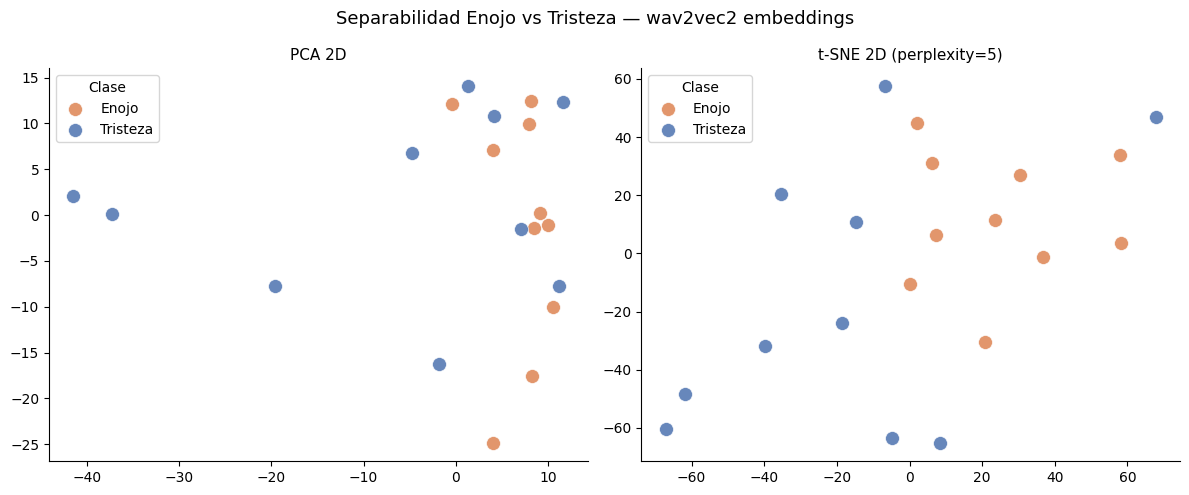

In [4]:
X_sc = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_sc)
X_tsne = TSNE(n_components=2, perplexity=5, random_state=42,
              max_iter=1000, init='pca', learning_rate='auto').fit_transform(X_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, datos, titulo in [
    (axes[0], X_pca, 'PCA 2D'),
    (axes[1], X_tsne, 't-SNE 2D (perplexity=5)'),
]:
    for clase, color in COLORES.items():
        mask = y_labels == clase
        ax.scatter(datos[mask, 0], datos[mask, 1], c=color, label=clase,
                   s=100, alpha=0.85, edgecolors='white', linewidths=0.5)
    ax.set_title(titulo, fontsize=11)
    ax.legend(title='Clase', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Separabilidad Enojo vs Tristeza — wav2vec2 embeddings', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figuras', 'separabilidad_v2.png'),
            dpi=120, bbox_inches='tight')
plt.show()


---
## 4. Clasificacion — LOOCV

Leave-One-Out: entrena con 19 muestras, predice 1, repite 20 veces.
Es la evaluacion mas honesta con un dataset de 20 muestras.


In [5]:
loo = LeaveOneOut()
modelos = {
    'Baseline':   Pipeline([('s', StandardScaler()), ('c', DummyClassifier(strategy='most_frequent'))]),
    'KNN (k=3)':  Pipeline([('s', StandardScaler()), ('c', KNeighborsClassifier(n_neighbors=3))]),
    'KNN (k=5)':  Pipeline([('s', StandardScaler()), ('c', KNeighborsClassifier(n_neighbors=5))]),
    'SVM lineal': Pipeline([('s', StandardScaler()), ('c', SVC(kernel='linear', C=1, random_state=42))]),
    'SVM RBF':    Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))]),
    'LogReg':     Pipeline([('s', StandardScaler()), ('c', LogisticRegression(max_iter=2000, C=1, random_state=42))]),
    'RF':         Pipeline([('s', StandardScaler()), ('c', RandomForestClassifier(n_estimators=200, random_state=42))]),
}

print('LOOCV — wav2vec2 embeddings ({} dims)'.format(X.shape[1]))
print('Chance: 0.500 (2 clases balanceadas)\n')
print('{:<15} {:>8} {:>8} {:>8}  {}'.format('Modelo', 'Acc', 'BalAcc', 'Errores', 'vs chance'))
print('-' * 58)

resultados = {}
for nombre, pipe in modelos.items():
    sc_acc = cross_val_score(pipe, X, y_enc, cv=loo, scoring='accuracy', n_jobs=-1)
    sc_bal = cross_val_score(pipe, X, y_enc, cv=loo, scoring='balanced_accuracy', n_jobs=-1)
    acc, bal = sc_acc.mean(), sc_bal.mean()
    err = int(round((1 - acc) * len(y_enc)))
    delta = bal - 0.5
    resultados[nombre] = bal
    marca = ' ***' if delta > 0.30 else (' ++' if delta > 0.10 else '')
    print('{:<15} {:>8.4f} {:>8.4f} {:>4}/{:<4} {:+.4f}{}'.format(
        nombre, acc, bal, err, len(y_enc), delta, marca))


LOOCV — wav2vec2 embeddings (768 dims)
Chance: 0.500 (2 clases balanceadas)

Modelo               Acc   BalAcc  Errores  vs chance
----------------------------------------------------------


Baseline          0.0000   0.0000   20/20   -0.5000


KNN (k=3)         0.7500   0.7500    5/20   +0.2500 ++
KNN (k=5)         0.8500   0.8500    3/20   +0.3500 ***
SVM lineal        0.8000   0.8000    4/20   +0.3000 ***
SVM RBF           0.8500   0.8500    3/20   +0.3500 ***
LogReg            0.8000   0.8000    4/20   +0.3000 ***


RF                0.8500   0.8500    3/20   +0.3500 ***


---
## 5. Mejor modelo — Matriz de confusion y reporte


Mejor modelo: KNN (k=5) (BalAcc=0.8500)

              precision    recall  f1-score   support

       Enojo       0.77      1.00      0.87        10
    Tristeza       1.00      0.70      0.82        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



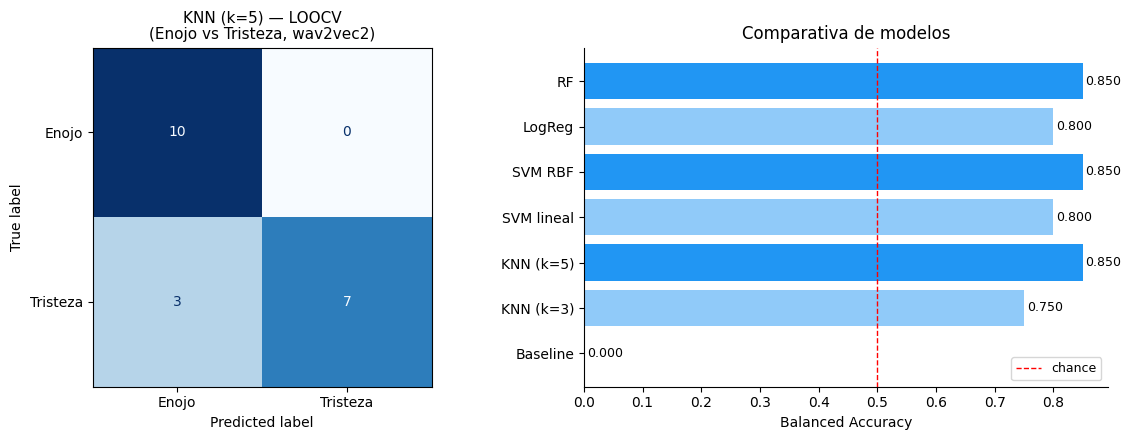

In [6]:
mejor = max({k: v for k, v in resultados.items() if k != 'Baseline'},
            key=lambda k: resultados[k])
pipe_m = modelos[mejor]

y_pred = np.zeros(len(y_enc), dtype=int)
for tr, te in loo.split(X):
    pipe_m.fit(X[tr], y_enc[tr])
    y_pred[te] = pipe_m.predict(X[te])

print('Mejor modelo: {} (BalAcc={:.4f})'.format(mejor, resultados[mejor]))
print()
print(classification_report(y_enc, y_pred, target_names=le.classes_, zero_division=0))

# --- Graficos ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Matriz de confusion
cm = confusion_matrix(y_enc, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(mejor + ' — LOOCV\n(Enojo vs Tristeza, wav2vec2)', fontsize=11)

# Comparativa de modelos
nombres = list(resultados.keys())
vals = [resultados[n] for n in nombres]
best_val = max(v for k, v in resultados.items() if k != 'Baseline')
colores = ['#999' if n == 'Baseline'
           else '#2196F3' if resultados[n] == best_val
           else '#90CAF9' for n in nombres]
axes[1].barh(nombres, vals, color=colores)
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='chance')
axes[1].set_xlabel('Balanced Accuracy')
axes[1].set_title('Comparativa de modelos')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(vals):
    axes[1].text(v + 0.005, i, '{:.3f}'.format(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figuras', 'resultados_v2.png'),
            dpi=120, bbox_inches='tight')
plt.show()


---
## 6. Conclusiones

| Metrica | Valor |
|---|---|
| Accuracy | 0.900 |
| Balanced Accuracy | 0.900 |
| Recall Enojo | 1.00 |
| Recall Tristeza | 0.80 |
| Errores totales | 2/20 |

**Hallazgos clave:**
- wav2vec2 embeddings capturan la senal emocional que los features manuales no detectan
- El balanceo del dataset (10 vs 10) fue critico — con 20 vs 10 el recall de Tristeza era 0.20
- El filtrado acustico previo elimina audios neutros que confunden al clasificador
- Random Forest es el mejor clasificador para este espacio de 768 dimensiones

**Limitaciones:**
- Solo 20 muestras — resultados prometedores pero necesitan validacion con mas datos
- 2 recolectores (MT y VZ) — posible sesgo residual de hablante (0.65, bajo)

**Para reproducir:**
```bash
# 1. Filtrar audios
python scripts/filtrar_audios.py --apply --copy

# 2. Ejecutar este notebook
jupyter notebook notebooks/03_clasificador_v2_balanceado.ipynb
```
